# Exploratory Data Analysis on Superstore Dataset

This project performs Exploratory Data Analysis (EDA) on the Superstore dataset. The objective is to analyze sales, profit, customer behavior, and identify key business insights.

sns.set_style("whitegrid")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import pandas as pd

df = pd.read_csv("superstore.csv", encoding='latin1')

## Data Understanding

The dataset contains information about sales, profit, customers, and products across different regions.

In [2]:
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,è®°å½æ°,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [3]:
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'è®°å½æ°', 'Order.Date', 'Order.ID',
       'Order.Priority', 'Product.ID', 'Product.Name', 'Profit', 'Quantity',
       'Region', 'Row.ID', 'Sales', 'Segment', 'Ship.Date', 'Ship.Mode',
       'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [4]:
df.columns = df.columns.str.strip()

## Data Cleaning

In this step, unnecessary columns are removed and data is prepared for analysis.

In [5]:
df = df.loc[:, ~df.columns.str.contains('记录', regex=True)]

In [6]:
'记录数' in df.columns

False

In [7]:
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   è®°å½æ°       51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

## Statistical Summary

This provides summary statistics of numerical columns.

In [8]:
df.describe()

,Discount,è®°å½æ°,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51285.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.378062,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.299145,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


## Category Analysis

Analyzing product categories and their impact on sales.

<Axes: title={'center': 'Count of Orders by Category'}, xlabel='Category'>

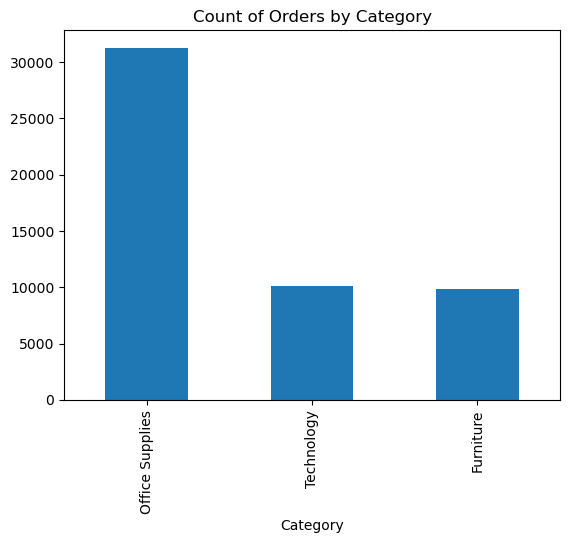

In [9]:
df['Category'].value_counts().plot(kind='bar', title='Count of Orders by Category')

Office Supplies has the highest number of orders followed by Technology and Furniture.

<Axes: title={'center': 'Sales by Category'}, xlabel='Category'>

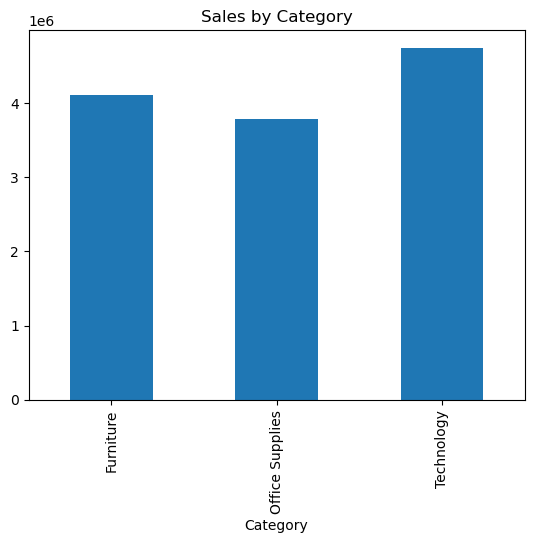

In [10]:
df.groupby('Category')['Sales'].sum().plot(kind='bar', title='Sales by Category')

Technology category generates the highest sales.

<Axes: title={'center': 'Profit by Category'}, xlabel='Category'>

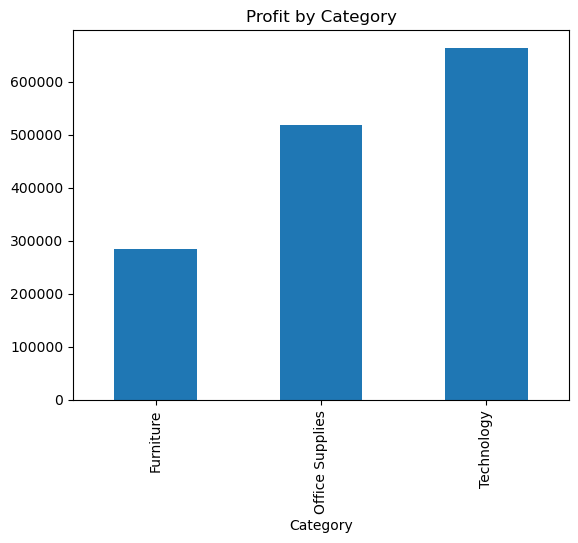

In [11]:
df.groupby('Category')['Profit'].sum().plot(kind='bar', title='Profit by Category')

Technology category contributes the highest profit.

## Sales Distribution

<Axes: >

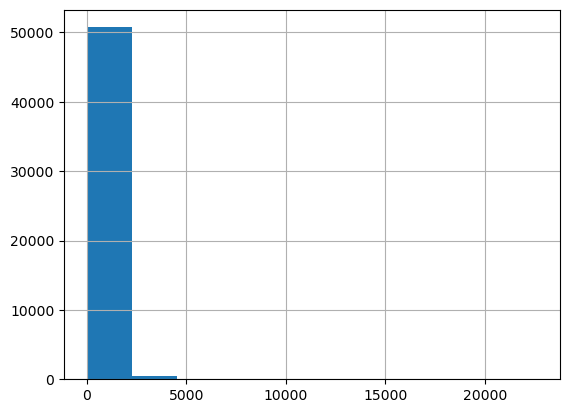

In [12]:
df['Sales'].hist()

Most sales are small with a few high-value transactions.

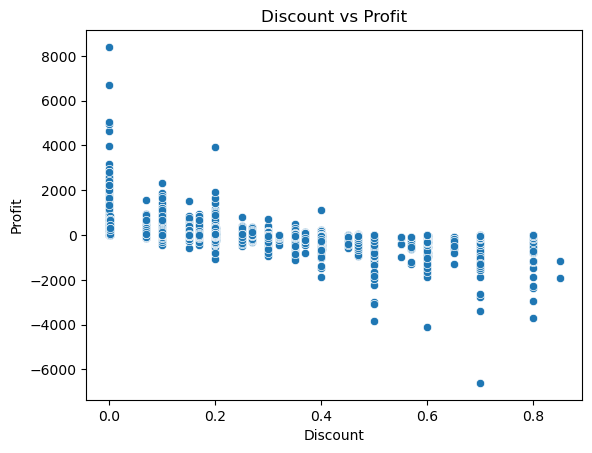

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.show()

In [16]:
import warnings
warnings.filterwarnings('ignore')

## Correlation Analysis

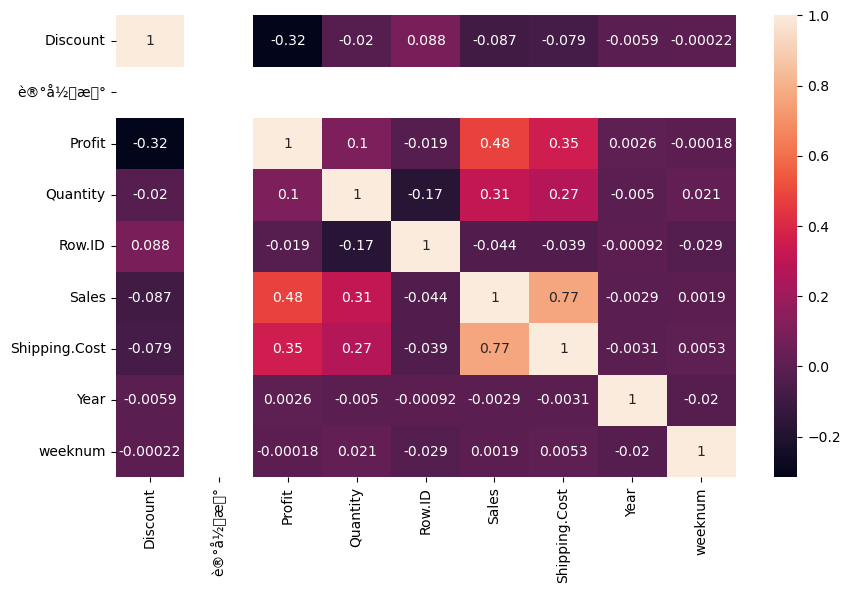

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

Sales and Profit are positively correlated while Discount negatively impacts Profit.

## Region Analysis

<Axes: title={'center': 'Profit by Segment'}, xlabel='Segment'>

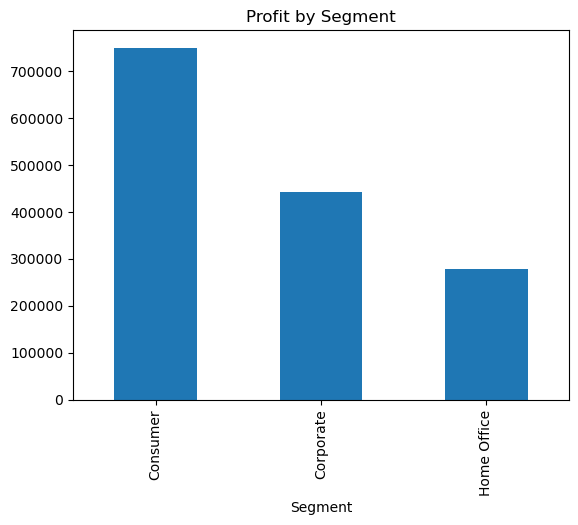

In [19]:
df.groupby('Segment')['Profit'].sum().plot(kind='bar', title='Profit by Segment')

Western region has the highest sales.

<Axes: xlabel='City'>

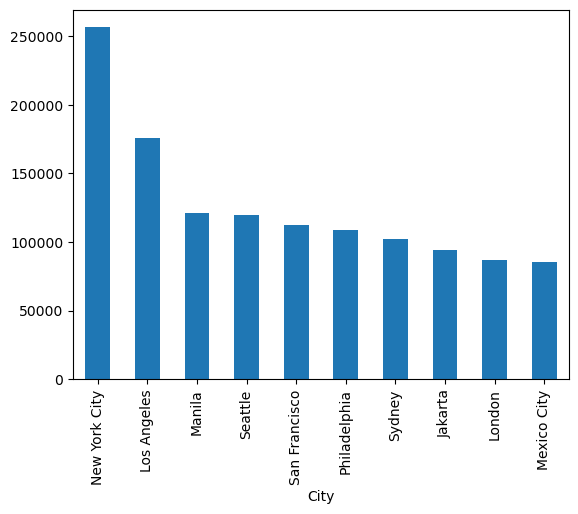

In [20]:
df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

## Sales Trend Over Time

<Axes: title={'center': 'Sales Trend Over Years'}, xlabel='Year'>

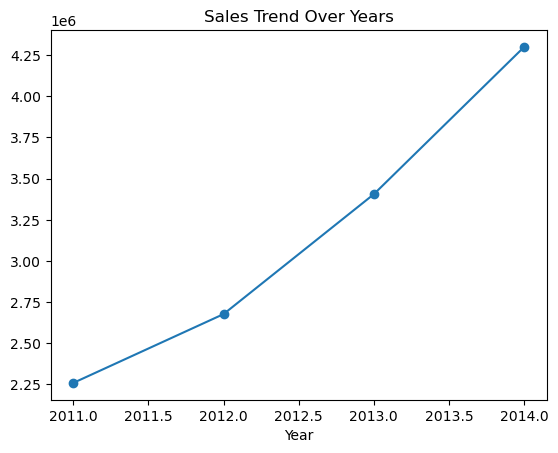

In [21]:
df.groupby('Year')['Sales'].sum().plot(kind='line', marker='o', title='Sales Trend Over Years')

Sales show growth over the years.

## Conclusion

The analysis shows that Technology category drives the highest sales and profit. Discounts negatively impact profitability. The Western region contributes the most to sales, and overall business is growing steadily.